# Understanding BERT in NLP: Working, Internal Logic, and Real-World Applications

This notebook is designed for beginners who want to understand how BERT works in Natural Language Processing (NLP).

The notebook explains:

- what BERT is
- why contextual understanding matters
- how BERT tokenizes text
- how input embeddings are formed
- how masked language modeling works
- how contextual embeddings differ across sentences
- where BERT is used in real-world NLP applications

This is not just a model demo. The goal is to understand the logic behind BERT step by step.

In [2]:
#install libraries
!pip -q install transformers datasets sentencepiece

In [3]:
#import libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertModel, BertForMaskedLM
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

## 1. What is BERT?

**BERT** stands for **Bidirectional Encoder Representations from Transformers**.

### Simple definition
BERT is a deep learning language model that learns the meaning of words by looking at the words before and after them.

### Why this matters
In natural language, the meaning of a word often depends on context.

Example:

- "He sat on the **bank** of the river."
- "She went to the **bank** to deposit money."

The word **bank** has different meanings in these two sentences.

Older word embedding methods usually assign one fixed vector to a word.
BERT creates a **context-aware representation**, so the same word can have different embeddings in different sentences.

### Main idea
BERT uses:
- subword tokenization
- transformer encoder layers
- self-attention
- contextual embeddings

### Common real-world uses
- sentiment analysis
- question answering
- document classification
- named entity recognition
- semantic search
- chatbots

In [4]:
# Loading the tokenizer and the base BERT model
# bert-base-uncased uses lowercase English text

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_hidden_states=True)
model.eval()

mlm_model = BertForMaskedLM.from_pretrained("bert-base-uncased")
mlm_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

## 2. What is tokenization?

Before BERT can process text, the text must be broken into smaller units called **tokens**.

BERT uses **WordPiece tokenization**.

### Simple definition
WordPiece splits text into words or subwords.

This helps the model handle:
- rare words
- long words
- unseen words
- spelling variations

Example:
- `playing` may remain one token
- a rarer word may split into parts such as `electro`, `##magnetic`

The `##` means the token is a continuation of the previous subword.

In [5]:
#tokenization example
sample_words = [
    "playing",
    "unbelievable",
    "electromagnetism",
    "misunderstanding",
    "bioinformatics"
]

for word in sample_words:
    tokens = tokenizer.tokenize(word)
    print(f"{word:20} -> {tokens}")

playing              -> ['playing']
unbelievable         -> ['unbelievable']
electromagnetism     -> ['electro', '##ma', '##gne', '##tism']
misunderstanding     -> ['misunderstanding']
bioinformatics       -> ['bio', '##in', '##form', '##atics']


In [6]:
#tokenization of a sentence
sentence = "BERT helps computers understand language in context."

tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Original sentence:")
print(sentence)
print("\nTokens:")
print(tokens)
print("\nToken IDs:")
print(token_ids)

Original sentence:
BERT helps computers understand language in context.

Tokens:
['bert', 'helps', 'computers', 'understand', 'language', 'in', 'context', '.']

Token IDs:
[14324, 7126, 7588, 3305, 2653, 1999, 6123, 1012]


## 3. Special tokens in BERT

BERT adds special tokens to the input.

### Important special tokens

- **[CLS]**  
  Added at the beginning of the sentence.  
  Its final representation is often used for classification tasks.

- **[SEP]**  
  Marks the end of a sentence.  
  Also used to separate sentence pairs.

- **[PAD]**  
  Used when sequences are padded to the same length.

- **[MASK]**  
  Used during masked language modeling.

These tokens help BERT understand input structure.

In [8]:
encoded = tokenizer(sentence, return_tensors="pt")

print("Input IDs:")
print(encoded["input_ids"])
print("\nAttention Mask:")
print(encoded["attention_mask"])

decoded_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
print("\nTokens including special tokens:")
print(decoded_tokens)

Input IDs:
tensor([[  101, 14324,  7126,  7588,  3305,  2653,  1999,  6123,  1012,   102]])

Attention Mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Tokens including special tokens:
['[CLS]', 'bert', 'helps', 'computers', 'understand', 'language', 'in', 'context', '.', '[SEP]']


## 4. How BERT represents input

BERT does not use only token embeddings.

For each token, BERT combines three types of information:

### 1. Token Embeddings
These represent the token itself.

### 2. Position Embeddings
These represent the position of the token in the sequence.

### 3. Segment Embeddings
These tell BERT whether a token belongs to sentence A or sentence B.

### Final input embedding
The actual input to BERT is the sum of:

**Token Embedding + Position Embedding + Segment Embedding**

This lets BERT know:
- what the token is
- where it appears
- which sentence it belongs to

In [9]:
#inspect shapes of embeddings
inputs = tokenizer("BERT is a contextual language model.", return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

last_hidden_state = outputs.last_hidden_state
hidden_states = outputs.hidden_states

print("Last hidden state shape:")
print(last_hidden_state.shape)

print("\nNumber of hidden state tensors:")
print(len(hidden_states))

print("\nShape of one hidden layer:")
print(hidden_states[0].shape)

Last hidden state shape:
torch.Size([1, 10, 768])

Number of hidden state tensors:
13

Shape of one hidden layer:
torch.Size([1, 10, 768])


In [10]:
# explain the output shapes in a simple way

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Understanding the output:\n")
print(f"Last hidden state shape : {last_hidden_state.shape}")
print(f"Number of hidden states : {len(hidden_states)}")
print(f"One hidden layer shape  : {hidden_states[0].shape}\n")

print("Interpretation:")
print(f"- Batch size = {last_hidden_state.shape[0]} (one input sentence)")
print(f"- Number of tokens = {last_hidden_state.shape[1]} (includes special tokens)")
print(f"- Hidden size = {last_hidden_state.shape[2]} (each token gets a 768-dimensional vector)\n")

print("Tokens in the input:")
for i, token in enumerate(tokens):
    print(f"{i:2d} -> {token}")

print("\nWhy are there 13 hidden states?")
print("- 1 embedding output layer")
print("- 12 transformer encoder layers")
print("- Total = 13\n")

print("Each token has its own contextual embedding.")
print("Example: embedding shape for the first token:")
print(last_hidden_state[0, 0].shape)

Understanding the output:

Last hidden state shape : torch.Size([1, 10, 768])
Number of hidden states : 13
One hidden layer shape  : torch.Size([1, 10, 768])

Interpretation:
- Batch size = 1 (one input sentence)
- Number of tokens = 10 (includes special tokens)
- Hidden size = 768 (each token gets a 768-dimensional vector)

Tokens in the input:
 0 -> [CLS]
 1 -> bert
 2 -> is
 3 -> a
 4 -> context
 5 -> ##ual
 6 -> language
 7 -> model
 8 -> .
 9 -> [SEP]

Why are there 13 hidden states?
- 1 embedding output layer
- 12 transformer encoder layers
- Total = 13

Each token has its own contextual embedding.
Example: embedding shape for the first token:
torch.Size([768])


## 5. Self-attention: the main idea behind BERT

BERT is built using the **Transformer encoder**.

The key mechanism inside the transformer is **self-attention**.

### Simple definition
Self-attention allows each word to look at other words in the sentence and decide which ones are important for understanding its meaning.

Example:

Sentence:  
**"The animal didn't cross the street because it was too tired."**

To understand **"it"**, the model must look at other words such as:
- animal
- cross
- tired

This means BERT does not read text one word at a time like older sequential models.
It looks at relationships between words across the full sentence.

### Why this is useful
Self-attention helps BERT:
- resolve ambiguity
- understand context
- model long-range dependencies
- create context-sensitive representations

## 6. Same word, different meaning

A major strength of BERT is that the same word can get different embeddings in different contexts.

We will compare the word **bank** in two sentences:

- "He sat near the bank of the river."
- "She visited the bank to open an account."

If BERT is working contextually, the embeddings for **bank** should differ.

In [11]:
sent1 = "He sat near the bank of the river."
sent2 = "She visited the bank to open an account."

def get_token_embedding(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs)

    last_hidden = outputs.last_hidden_state[0]

    target_positions = [i for i, tok in enumerate(tokens) if tok == target_word]
    if not target_positions:
        return None, tokens

    pos = target_positions[0]
    return last_hidden[pos].numpy(), tokens

emb1, tokens1 = get_token_embedding(sent1, "bank")
emb2, tokens2 = get_token_embedding(sent2, "bank")

print("Sentence 1 tokens:")
print(tokens1)
print("\nSentence 2 tokens:")
print(tokens2)

sim = cosine_similarity([emb1], [emb2])[0][0]
print(f"\nCosine similarity between 'bank' embeddings: {sim:.4f}")

Sentence 1 tokens:
['[CLS]', 'he', 'sat', 'near', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']

Sentence 2 tokens:
['[CLS]', 'she', 'visited', 'the', 'bank', 'to', 'open', 'an', 'account', '.', '[SEP]']

Cosine similarity between 'bank' embeddings: 0.5052


### Interpreting the contextual difference

The cosine similarity score above compares the embedding of the word **bank** in two different sentences.

Although the surface form of the word is the same, BERT generates different contextual embeddings because the surrounding words are different.

- In the first sentence, **bank** refers to the side of a river.
- In the second sentence, **bank** refers to a financial institution.

This shows that BERT does not assign one fixed meaning to a word.  
Instead, it builds the meaning from context.

## 7. How BERT learns: Masked Language Modeling (MLM)

One of the original training tasks used in BERT is **Masked Language Modeling**.

### Simple definition
Some words in a sentence are hidden using `[MASK]`, and BERT tries to predict the missing word.

Example:
- "The cat sat on the `[MASK]`."

Possible prediction:
- mat

### Why this helps
To predict the missing word, BERT must use both left and right context.

This is one reason BERT is called **bidirectional**.
It learns from the full context surrounding the masked token.

In [13]:
masked_text = "The cat sat on the [MASK]."
inputs = tokenizer(masked_text, return_tensors="pt")

with torch.no_grad():
    outputs = mlm_model(**inputs)

logits = outputs.logits
mask_token_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]

predicted_token_id = logits[0, mask_token_index].argmax(axis=-1)
predicted_token = tokenizer.decode(predicted_token_id)

print("Masked sentence:")
print(masked_text)
print("\nPredicted word:")
print(predicted_token)

Masked sentence:
The cat sat on the [MASK].

Predicted word:
floor


In [14]:
with torch.no_grad():
    outputs = mlm_model(**inputs)

mask_index = mask_token_index.item()
mask_logits = outputs.logits[0, mask_index]
top_k = 10
top_tokens = torch.topk(mask_logits, top_k)

top_ids = top_tokens.indices.tolist()
top_scores = top_tokens.values.tolist()
top_words = tokenizer.convert_ids_to_tokens(top_ids)

df_preds = pd.DataFrame({
    "Predicted Token": top_words,
    "Score": top_scores
})

print(df_preds)

  Predicted Token      Score
0           floor  11.748388
1             bed  10.776855
2           couch  10.669991
3            sofa  10.097303
4          ground  10.006363
5             rug   8.953586
6           table   8.874126
7           porch   8.762096
8         counter   8.737038
9           chair   8.683641


In [15]:
examples = [
    "Paris is the [MASK] of France.",
    "The doctor checked the patient's [MASK].",
    "Students submit assignments before the [MASK]."
]

for text in examples:
    inputs = tokenizer(text, return_tensors="pt")

    with torch.no_grad():
        outputs = mlm_model(**inputs)

    logits = outputs.logits
    mask_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    predicted_id = logits[0, mask_index].argmax(axis=-1)
    predicted_word = tokenizer.decode(predicted_id)

    print(f"Input   : {text}")
    print(f"Output  : {predicted_word}")
    print("-" * 60)

Input   : Paris is the [MASK] of France.
Output  : capital
------------------------------------------------------------
Input   : The doctor checked the patient's [MASK].
Output  : pulse
------------------------------------------------------------
Input   : Students submit assignments before the [MASK].
Output  : class
------------------------------------------------------------


## 8. Another original BERT training task: Next Sentence Prediction (NSP)


BERT is given two sentences and learns to predict whether the second sentence logically follows the first one.

Example:

Sentence A: "She went to the library."  
Sentence B: "She borrowed a book."

This pair is logically related.

But this pair is not:

Sentence A: "She went to the library."  
Sentence B: "The mango is very sweet."

### Why NSP was useful
This task helped BERT learn relationships between sentence pairs.

It was especially relevant for:
- question answering
- natural language inference
- sentence pair classification

## 9. What happens inside BERT layers?

BERT-base has multiple transformer encoder layers.

Each layer updates the token representations.

### Intuition
- Early layers capture simpler patterns
- Middle layers capture richer context
- Later layers capture task-relevant semantic information

The vector for a token changes as it passes through the layers.
This is why BERT embeddings are called **deep contextual embeddings**.

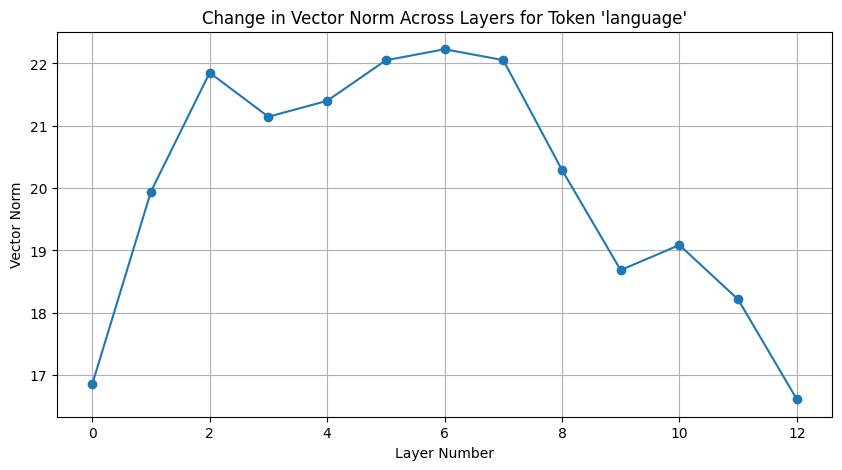

In [16]:
sentence = "Natural language processing is interesting."
inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

target_token = "language"
target_idx = tokens.index(target_token)

layer_vectors = [hidden_states[i][0, target_idx].numpy() for i in range(len(hidden_states))]
norms = [np.linalg.norm(vec) for vec in layer_vectors]

plt.figure(figsize=(10, 5))
plt.plot(range(len(norms)), norms, marker='o')
plt.title(f"Change in Vector Norm Across Layers for Token '{target_token}'")
plt.xlabel("Layer Number")
plt.ylabel("Vector Norm")
plt.grid(True)
plt.show()

## 10. Real-world applications of BERT

BERT is widely used in practical NLP systems.

### 1. Text Classification
Used for:
- sentiment analysis
- spam detection
- topic classification
- legal document categorization

### 2. Named Entity Recognition
Used to identify:
- person names
- organizations
- locations
- diseases
- case references

### 3. Question Answering
Used in:
- customer support bots
- FAQ systems
- educational assistants
- search interfaces

### 4. Semantic Search
Used to match:
- query and answer
- student question and learning material
- document and user need

### 5. Domain-specific BERT models
Different fields adapted BERT to their own vocabulary and data.

Examples:
- **BioBERT** for biomedical text
- **ClinicalBERT** for clinical notes
- **LegalBERT** for legal documents
- **FinBERT** for financial text

### Why this matters
The same architecture can be adapted to many real-world tasks by fine-tuning on domain-specific data.

## 11. Limitations of BERT

Although BERT is powerful, it has some limitations.

### 1. Computational Cost
BERT is heavier than simpler NLP models.

### 2. Input Length Limit
Standard BERT usually handles sequences up to 512 tokens.

### 3. Not Always the Best Choice
For some tasks, smaller or more efficient models may be preferred.

### 4. Domain Gap
A general BERT model may not perform well on specialized text unless it is adapted.

### 5. Interpretability
Even though attention helps, the full reasoning of deep models is still difficult to explain completely.

In [18]:
#Small interactive exploration cell
custom_text = "The teacher explained the lesson clearly."
inputs = tokenizer(custom_text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
embeddings = outputs.last_hidden_state[0].numpy()

print("Tokens:")
print(tokens)
print("\nEmbedding matrix shape:")
print(embeddings.shape)

Tokens:
['[CLS]', 'the', 'teacher', 'explained', 'the', 'lesson', 'clearly', '.', '[SEP]']

Embedding matrix shape:
(9, 768)


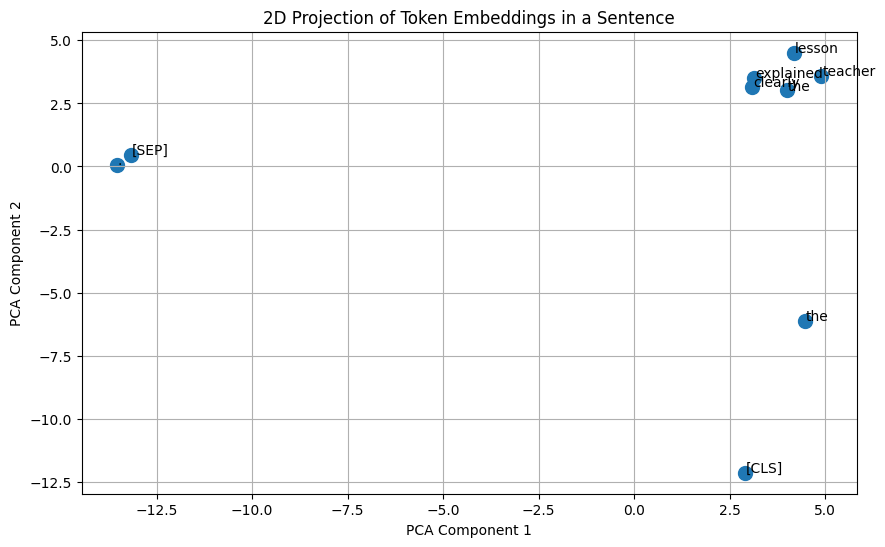

In [19]:
#Visualize token embeddings for one sentence
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=100)

for i, token in enumerate(tokens):
    plt.text(reduced[i, 0] + 0.02, reduced[i, 1] + 0.02, token)

plt.title("2D Projection of Token Embeddings in a Sentence")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

## 12. Conclusion

In this notebook, we studied BERT from a beginner's perspective.

We learned:

- what BERT means
- why contextual understanding is important
- how WordPiece tokenization works
- how BERT forms input representations
- how self-attention helps words interact with each other
- how masked language modeling trains BERT
- how the same word changes meaning across contexts
- where BERT is used in real-world NLP applications

BERT is important because it moved NLP from fixed word representations to context-aware language understanding.